In [8]:
import os, requests

import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from dotenv import load_dotenv
import networkx as nx
from matplotlib.patches import Arc
import matplotlib.colors as mcolors
import matplotlib.cm as cm

from itertools import combinations

load_dotenv()

True

In [ ]:
courses_url = "https://api.plaforedu.cluster.prd.app.rnp.br/courses/all"

params = {
    "includeFiled": False,
    "onlyPending": False,
    "registerLog": False,
    "orderByCreated": False,
    "orderByUpdated": False,
}

headers = {
    "accept": "application/json",
    "Content-Type": "application/json",
    "Cookie": f"id={os.getenv('COOCKIE_ID')}",
}

data = {
    "search": "",
    "hours": [],
    "institutions": [],
    "accessibilities": [],
    "itineraries": [],
    "competencies": [],
    "subThemes": [],
    "taxonomies": [],
}

response = requests.post(courses_url, headers=headers, params=params, json=data)

len(response.json()["data"])

In [10]:
all_competencies = []
all_categories = []

for curso in response.json()["data"]:
    competencies_list = curso.get('competencies', [])
    
    if not competencies_list:
        continue

    for comp in competencies_list:
        if comp.get('name'):
            all_competencies.append(comp['name'])
        
        categories_list = comp.get('categories', [])
        
        if not categories_list:
            continue
            
        for cat in categories_list:
            if cat.get('name'):
                all_categories.append(cat['name'])

In [11]:
df_competencies_freq = pd.Series(all_competencies).value_counts().reset_index()
df_competencies_freq.columns = ['competencia', 'frequencia']

df_categories_freq = pd.Series(all_categories).value_counts().reset_index()
df_categories_freq.columns = ['categoria', 'frequencia']

/var/folders/mq/3ctzq3zj4w737px9h791vs1r0000gn/T/ipykernel_2392/809621850.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


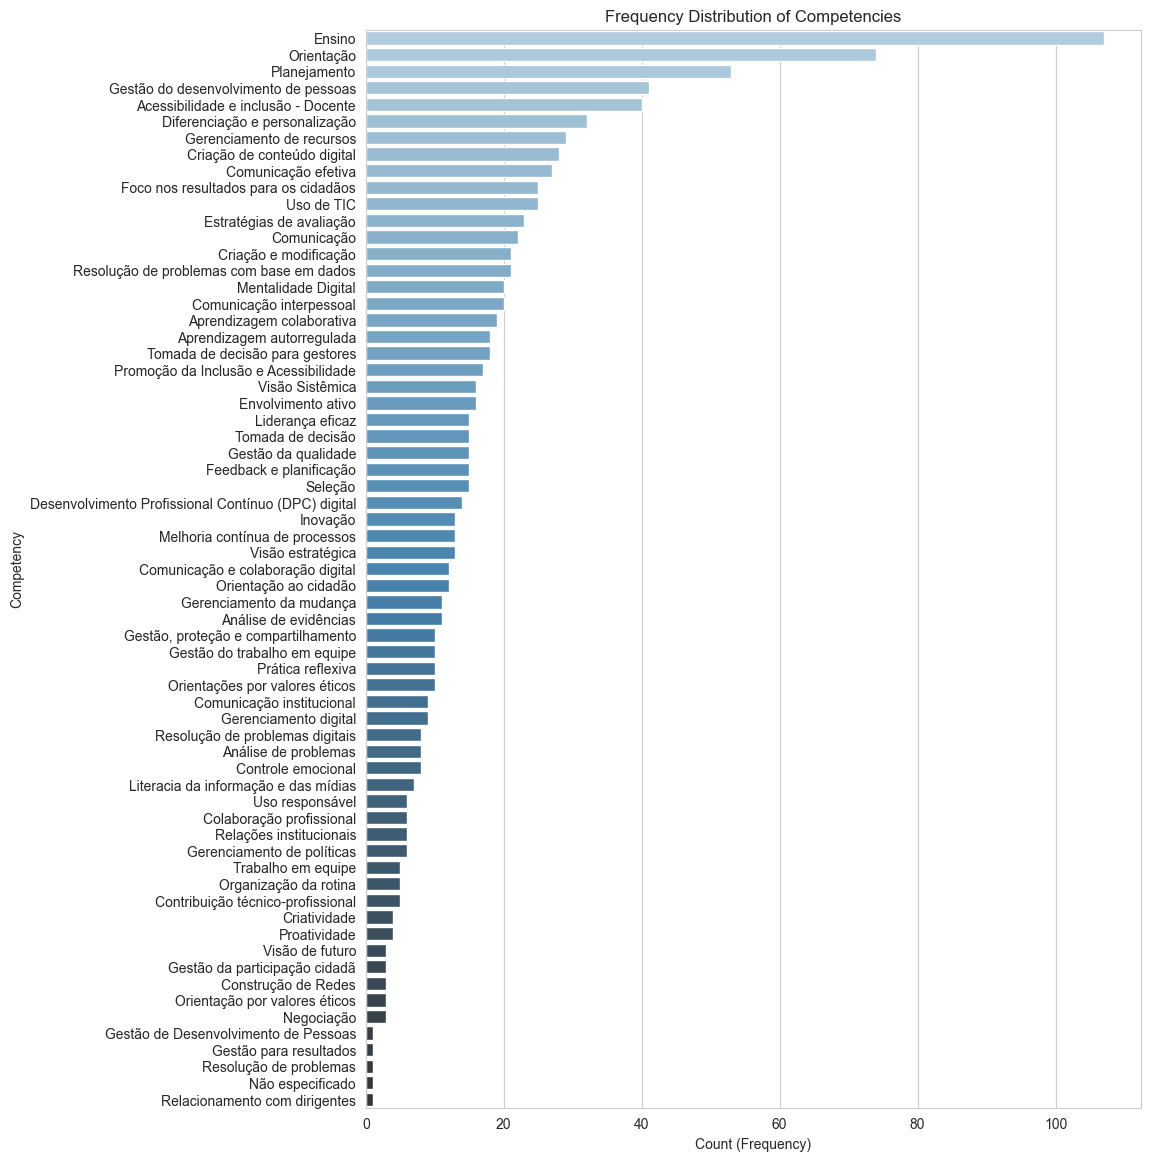

In [12]:
sns.set_style("whitegrid")
plt.figure(figsize=(10, 14))

sns.barplot(
    data=df_competencies_freq,
    x='frequencia',
    y='competencia',
    palette='Blues_d'
)

plt.title('Frequency Distribution of Competencies')
plt.xlabel('Count (Frequency)')
plt.ylabel('Competency')

plt.show()

In [29]:
df_competencies_freq.describe()

,frequencia
count,67.000000
mean,14.298507
std,16.404004
min,1.000000
25%,5.000000
50%,10.000000
75%,16.000000
max,107.000000


In [13]:
all_pairs = []

for curso in response.json()["data"]:
    comp_names = [
        comp.get('name') 
        for comp in curso.get('competencies', []) 
        if comp.get('name')
    ]

    if len(competencies_list) == 2:
        for pair in combinations(comp_names, 2):
            sorted_pair = tuple(sorted(pair))
            all_pairs.append(sorted_pair)

In [32]:
s_pairs_freq = pd.Series(all_pairs).value_counts()

df_pairs_freq = s_pairs_freq.reset_index()
df_pairs_freq.columns = ['par_de_competencias', 'frequencia']

df_pairs_freq

,par_de_competencias,frequencia
0,"(Ensino, Orientação)",71
1,"(Acessibilidade e inclusão - Docente, Diferenc...",26
2,"(Criação de conteúdo digital, Criação e modifi...",16
3,"(Aprendizagem colaborativa, Ensino)",15
4,"(Estratégias de avaliação, Feedback e planific...",14
...,...,...
712,"(Controle emocional, Resolução de problemas co...",1
713,"(Comunicação interpessoal, Resolução de proble...",1
714,"(Orientação ao cidadão, Resolução de problemas...",1
715,"(Foco nos resultados para os cidadãos, Organiz...",1


In [47]:
df_pairs_freq.iloc[0]["frequencia"] / df_pairs_freq["frequencia"].sum()

np.float64(0.04303030303030303)

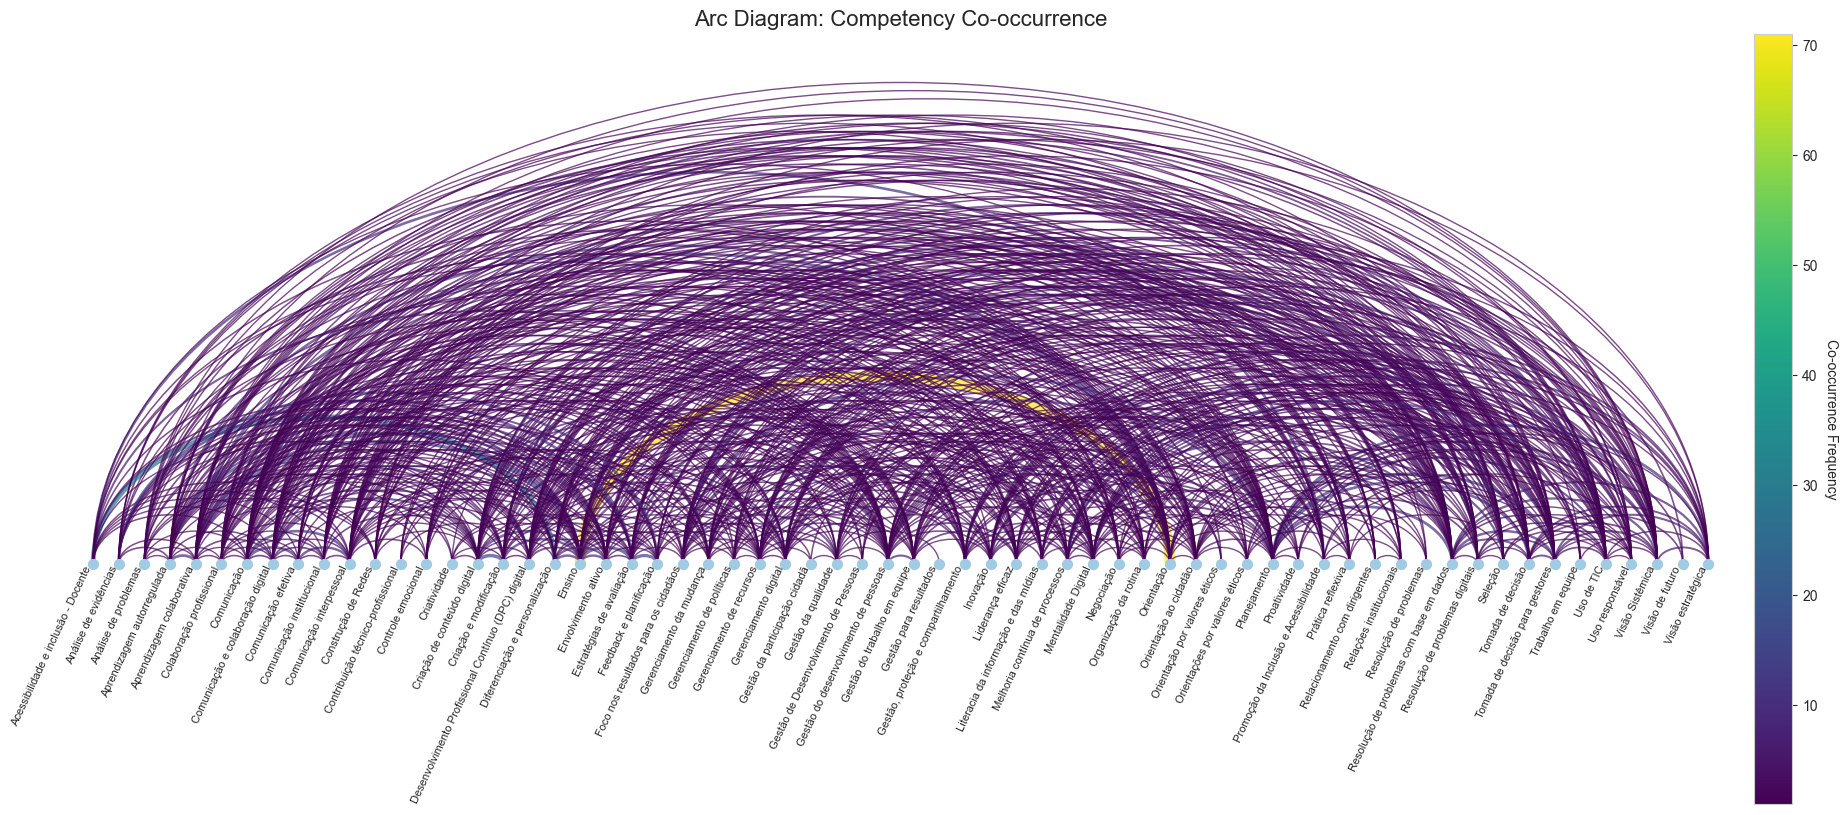

In [14]:
pairs_freq_series = pd.Series(all_pairs).value_counts()
df_pairs_freq = pairs_freq_series.reset_index()
df_pairs_freq.columns = ['competency_pair', 'frequency']

df_edges = df_pairs_freq.copy()
df_edges[['source', 'target']] = pd.DataFrame(
    df_edges['competency_pair'].tolist(),
    index=df_edges.index
)
df_edges = df_edges.rename(columns={'frequency': 'weight'})

G = nx.from_pandas_edgelist(
    df_edges,
    source='source',
    target='target',
    edge_attr='weight'
)

nodes = list(G.nodes())
nodes.sort()  # Sort nodes alphabetically
pos = {node: (i, 0) for i, node in enumerate(nodes)}

if not G.edges():
    print("No pairs found to draw.")
    weights = []
    min_weight = 0
    max_weight = 0
else:
    weights = [G[u][v]['weight'] for u, v in G.edges()]
    min_weight = min(weights)
    max_weight = max(weights)

if not weights or max_weight == min_weight:
    norm_weights = [3] * len(weights)  # Default line width
else:
    norm_weights = [
        1 + 7 * ((w - min_weight) / max(1, max_weight - min_weight))
        for w in weights
    ]

# Normalize colors
norm = mcolors.Normalize(vmin=min_weight, vmax=max(1, max_weight))
cmap = cm.Blues
sm = cm.ScalarMappable(cmap="viridis", norm=norm)
sm.set_array([])

fig_width = max(20, len(nodes) * 0.4)
fig, ax = plt.subplots(figsize=(fig_width, 10))

if G.edges():
    for i, (u, v) in enumerate(G.edges()):
        x1 = pos[u][0]
        x2 = pos[v][0]
        weight = weights[i]
        linewidth = norm_weights[i]
        color = sm.to_rgba(weight)

        arc_radius = abs(x2 - x1) / 2
        arc_center_x = (x1 + x2) / 2

        arc = Arc(
            (arc_center_x, 0),
            width=arc_radius * 2,
            height=arc_radius * 2,
            angle=0,
            theta1=0,
            theta2=180,
            color=color,
            linewidth=linewidth,
            alpha=0.7
        )
        ax.add_patch(arc)

nx.draw_networkx_nodes(
    G,
    pos,
    ax=ax,
    node_size=50,
    node_color='#a0cbe2'
)

for node, (x, y) in pos.items():
    ax.text(
        x,
        y - 0.05,
        node,
        fontsize=8,
        ha='right',
        va='top',
        rotation=65
    )

plt.title('Arc Diagram: Competency Co-occurrence', size=16)

if nodes:
    ax.set_xlim(pos[nodes[0]][0] - 1, pos[nodes[-1]][0] + 1)
if G.edges():
    max_radius = max([abs(pos[u][0] - pos[v][0]) / 2 for u, v in G.edges()], default=1)
    ax.set_ylim(-max_radius * 0.5, max_radius * 1.1)
else:
    ax.set_ylim(-1, 1)

if G.edges():
    cbar = plt.colorbar(sm, ax=ax, orientation='vertical', pad=0.01)
    cbar.set_label('Co-occurrence Frequency', rotation=270, labelpad=15)

plt.axis('off')
plt.show()

/var/folders/mq/3ctzq3zj4w737px9h791vs1r0000gn/T/ipykernel_2392/3048506724.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


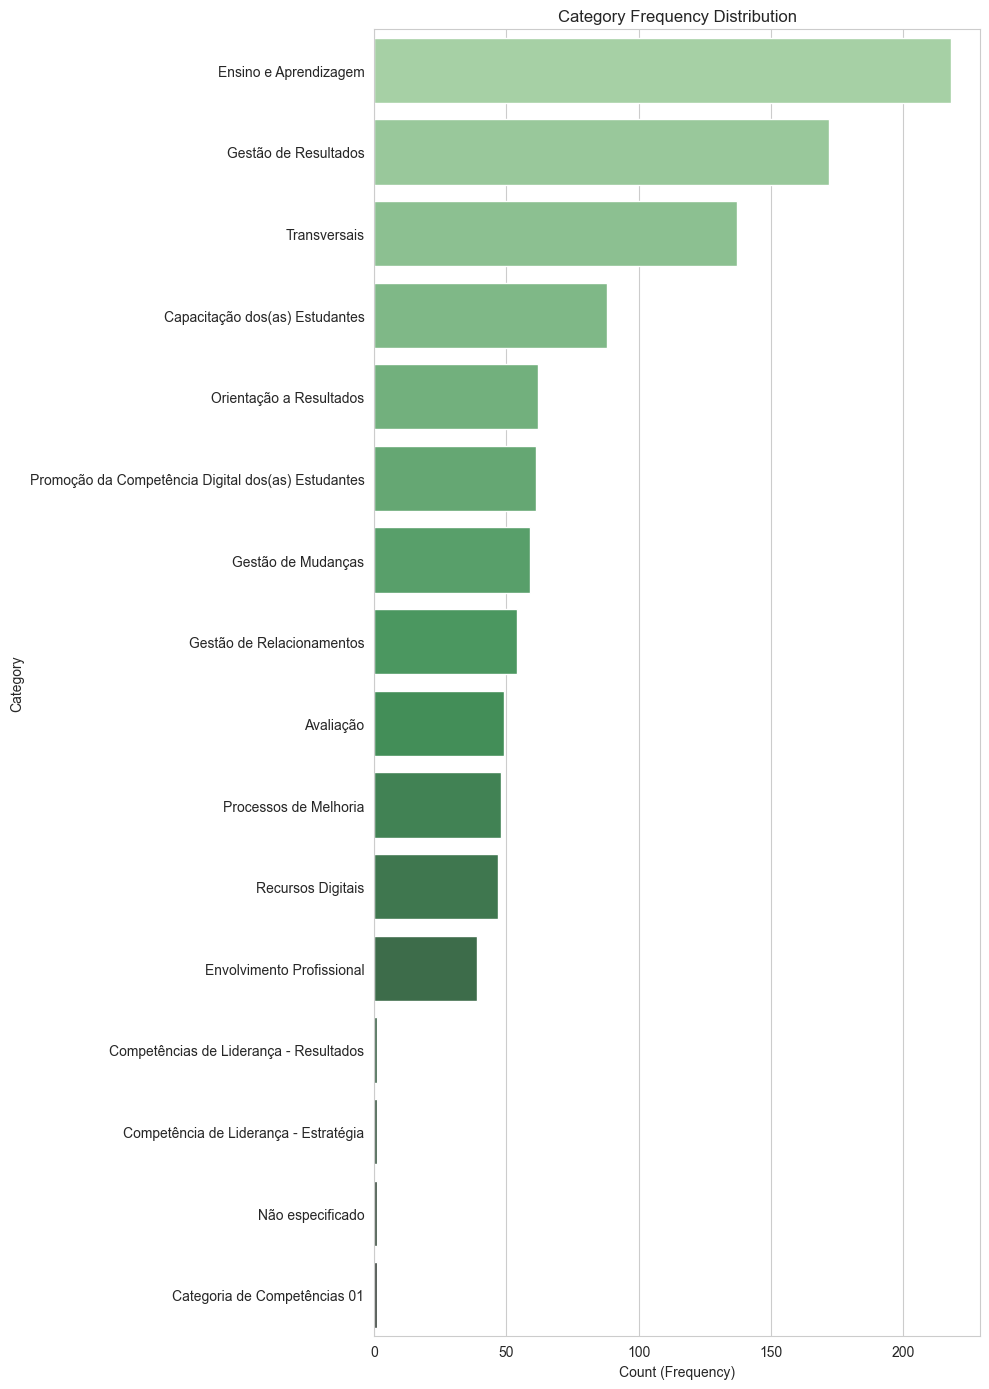

In [17]:
sns.set_style("whitegrid")
plt.figure(figsize=(10, 14))

sns.barplot(
    data=df_categories_freq,
    x='frequencia',
    y='categoria',
    palette='Greens_d'
)

plt.title('Category Frequency Distribution')
plt.xlabel('Count (Frequency)')
plt.ylabel('Category')

plt.tight_layout()

In [20]:
competency_counts = [len(curso.get('competencies', [])) for curso in response.json()["data"]]

df_counts = pd.DataFrame(competency_counts, columns=['num_competencias'])

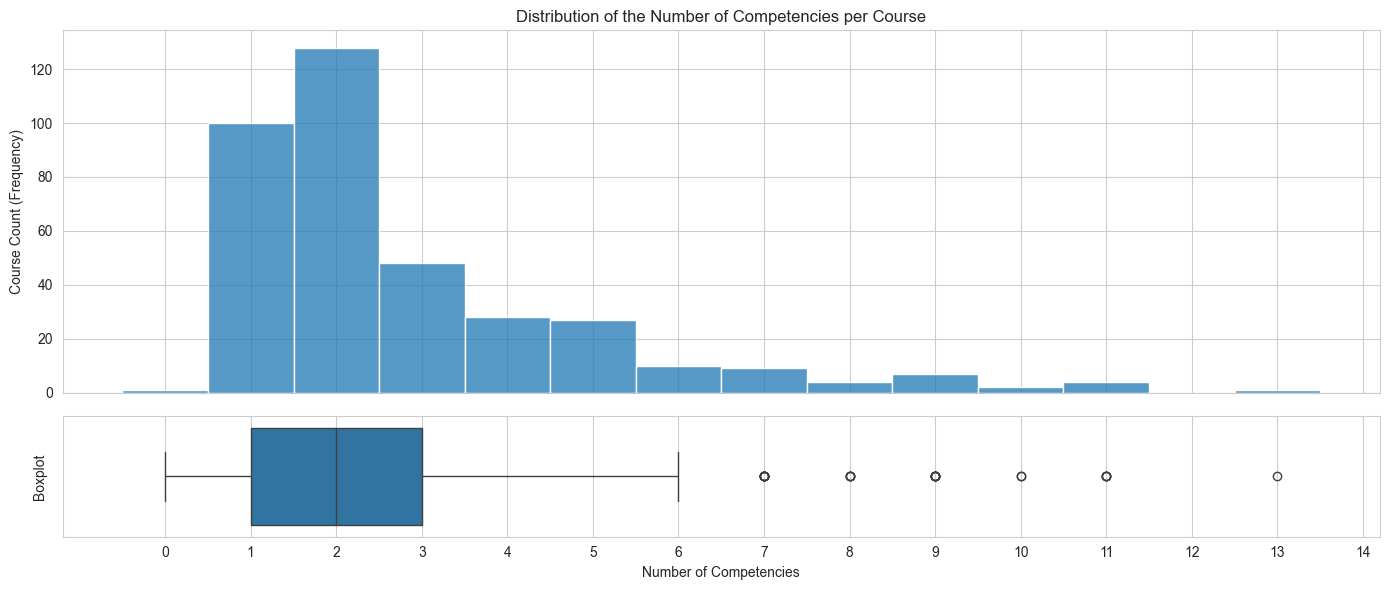

In [21]:
sns.set_style("whitegrid")

fig, axes = plt.subplots(
    2, 1,
    figsize=(14, 6),
    sharex=True,
    gridspec_kw={'height_ratios': [3, 1]}
)

sns.histplot(
    df_counts['num_competencias'],   # column name kept in Portuguese
    ax=axes[0],
    binwidth=1,
    discrete=True
)

axes[0].set_title('Distribution of the Number of Competencies per Course')
axes[0].set_ylabel('Course Count (Frequency)')
axes[0].set_xlabel('')

sns.boxplot(
    x=df_counts['num_competencias'],  # column name kept in Portuguese
    ax=axes[1]
)

axes[1].set_xlabel('Number of Competencies')
axes[1].set_ylabel('Boxplot')

max_comp = int(df_counts['num_competencias'].max())
min_comp = int(df_counts['num_competencias'].min())
axes[1].set_xticks(range(min_comp, max_comp + 2))

plt.tight_layout()
plt.show()

In [26]:
category_counts = []

for curso in response.json()["data"]:
    course_categories = set()

    # Iterate over competencies
    for comp in curso.get('competencies', []):

        # Iterate over categories inside each competency
        for cat in comp.get('categories', []):
            if cat.get('name'):
                course_categories.add(cat.get('name'))

    # Add the number of unique categories for this course to the list
    category_counts.append(len(course_categories))

df_counts = pd.DataFrame(category_counts, columns=['num_categorias'])

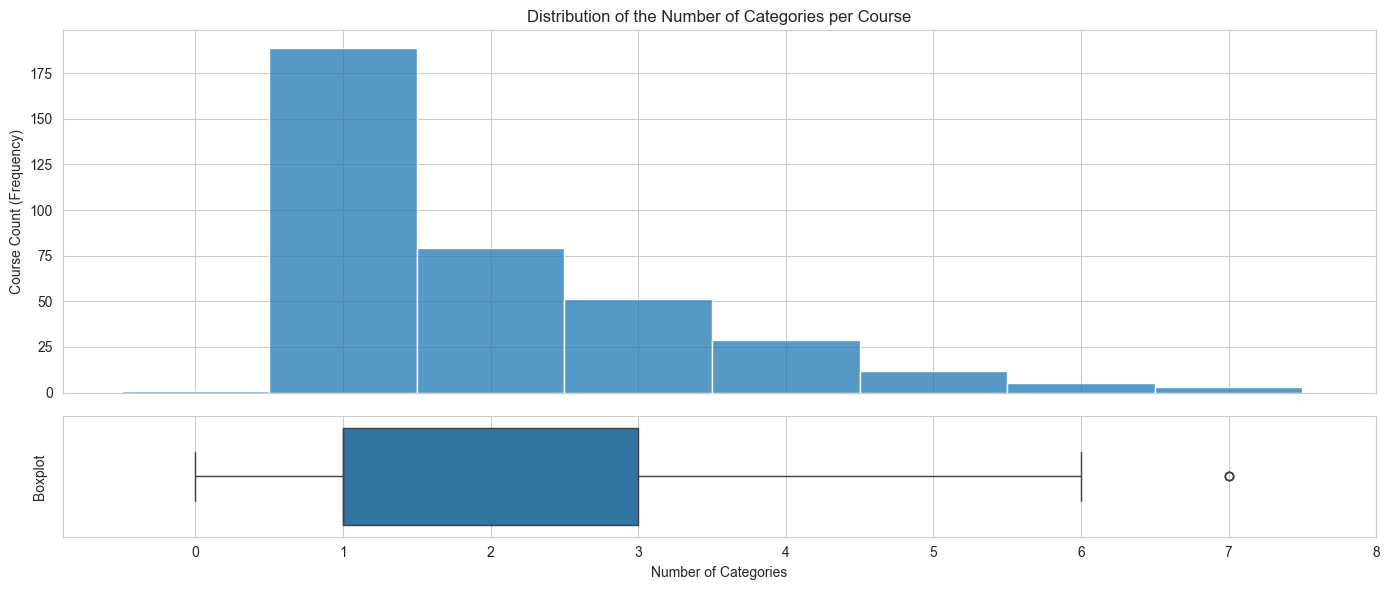

In [25]:
sns.set_style("whitegrid")

fig, axes = plt.subplots(
    2, 1,
    figsize=(14, 6),
    sharex=True,
    gridspec_kw={'height_ratios': [3, 1]}
)

sns.histplot(
    df_counts['num_categorias'],  # column name kept in Portuguese
    ax=axes[0],
    binwidth=1,
    discrete=True
)

axes[0].set_title('Distribution of the Number of Categories per Course')
axes[0].set_ylabel('Course Count (Frequency)')
axes[0].set_xlabel('')

sns.boxplot(
    x=df_counts['num_categorias'],  # column name kept in Portuguese
    ax=axes[1]
)

axes[1].set_xlabel('Number of Categories')
axes[1].set_ylabel('Boxplot')

max_comp = int(df_counts['num_categorias'].max())
min_comp = int(df_counts['num_categorias'].min())
axes[1].set_xticks(range(min_comp, max_comp + 2))

plt.tight_layout()
plt.show()

In [50]:
df_counts['num_categorias'].median()

np.float64(1.0)